<a href="https://colab.research.google.com/github/akanksha303/DeepLearning/blob/main/CNN/MnistDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Importing Libraries for Data Manipulation and Visualization**

This cell imports essential libraries for numerical operations, data handling, and plotting:
- `numpy` (as `np`): For numerical computing, especially with arrays.
- `pandas` (as `pd`): For data manipulation and analysis, primarily with DataFrames.
- `seaborn`: A high-level data visualization library based on `matplotlib`.
- `matplotlib.pyplot` (as `plt`): For creating static, interactive, and animated visualizations in Python.
- `warnings`: To manage warning messages, here used to filter them out for cleaner output.

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


### **Importing Libraries for Machine Learning Models and Utilities**

This cell imports libraries crucial for building and evaluating machine learning models, particularly neural networks:
- `sklearn.linear_model.Perceptron`: For implementing the Perceptron linear classifier.
- `sklearn.metrics`: To evaluate model performance using metrics like `accuracy_score`, `classification_report`, and `confusion_matrix`.
- `tensorflow.keras.models`: For defining neural network architectures.
- `tensorflow.keras.layers`: For various types of layers used in neural networks, including `Dense` (fully connected), `Convolution2D` (for convolutional layers), `Flatten` (to flatten input for dense layers), `MaxPooling2D` (for downsampling), and `Dropout` (for regularization).
- `tensorflow.keras.utils.to_categorical`: To convert class vectors (integers) to binary class matrices (one-hot encoding).

In [5]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras import models
from tensorflow.keras.layers import Dense, Convolution2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical

In [6]:
df = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")

In [7]:
df.head()

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df.shape

(22375, 785)

In [9]:
df.columns

Index(['5', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8',
       ...
       '0.608', '0.609', '0.610', '0.611', '0.612', '0.613', '0.614', '0.615',
       '0.616', '0.617'],
      dtype='object', length=785)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22375 entries, 0 to 22374
Columns: 785 entries, 5 to 0.617
dtypes: float64(523), int64(262)
memory usage: 134.0 MB


In [11]:
#preprocess

# Rename the first column to 'label' as it contains the digit labels
df = df.rename(columns={df.columns[0]: 'label'})
df_test = df_test.rename(columns={df_test.columns[0]: 'label'})

x_train = df.drop("label", axis=1).values
y_train = df["label"].values
x_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values

In [12]:
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

In [13]:
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

In [14]:
#one hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [15]:
perceptron = models.Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10, activation="softmax")
])

In [16]:
perceptron.compile(optimizer='sgd', loss="categorical_crossentropy", metrics =["accuracy"])

In [17]:
history = perceptron.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), verbose=1)

Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5675 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 9/10
700/700 ━━━━━

In [18]:
acc_prepcp = perceptron.evaluate(x_test, y_test, verbose=0)

In [19]:
acc_prepcp

[nan, 0.09800980240106583]

In [20]:
#ANN
ann = models.Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

In [21]:
ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics =["accuracy"])

In [22]:
histroy_ann= ann.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), verbose=1)

Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6398 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 9/10
700/700 ━━━━━

In [23]:
acc_ann = ann.evaluate(x_test, y_test, verbose=0)
print(acc_ann)

[nan, 0.09800980240106583]


In [24]:
acc_ann

[nan, 0.09800980240106583]

### Model Performance Comparison

In [25]:
X_train_cnn = x_train.reshape(-1, 28, 28, 1)
X_test_cnn = x_test.reshape(-1, 28, 28, 1)

In [26]:
#cnn
cnn = models.Sequential([
    Convolution2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Convolution2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [27]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics =["accuracy"])

In [28]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics =["accuracy"])

In [29]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics =["accuracy"])

In [30]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics =["accuracy"])
history_cnn = cnn.fit(X_train_cnn, y_train, epochs=10, validation_data=(X_test_cnn, y_test), verbose=1)

Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.1398 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 37s 32ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.0995 - loss: nan - val_accuracy: 0.0980 - val_loss: nan
Epoch 9/

In [31]:
validation_data = [X_test_cnn, y_test]
acc_cnn = cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(acc_cnn)

[nan, 0.09800980240106583]


### Model Predictions

### Model Predictions

In [40]:
import numpy as np

# Get predictions from Perceptron model
perceptron_predictions = perceptron.predict(x_test)
perceptron_predicted_labels = np.argmax(perceptron_predictions, axis=1)

# Get predictions from ANN model
ann_predictions = ann.predict(x_test)
ann_predicted_labels = np.argmax(ann_predictions, axis=1)

# Get predictions from CNN model
cnn_predictions = cnn.predict(X_test_cnn)
cnn_predicted_labels = np.argmax(cnn_predictions, axis=1)

# Get actual labels
actual_labels = np.argmax(y_test, axis=1)

# Display a few sample predictions
num_samples = 10
print(f"Displaying {num_samples} sample predictions:")
print("-------------------------------------------------------------------------------------------------------------------")
print(f"{'Sample #':<10} | {'Actual Label':<15} | {'Perceptron Prediction':<25} | {'ANN Prediction':<20} | {'CNN Prediction':<20}")
print("-------------------------------------------------------------------------------------------------------------------")
for i in range(num_samples):
    print(f"{i:<10} | {actual_labels[i]:<15} | {perceptron_predicted_labels[i]:<25} | {ann_predicted_labels[i]:<20} | {cnn_predicted_labels[i]:<20}")
print("-------------------------------------------------------------------------------------------------------------------")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step
Displaying 10 sample predictions:
-------------------------------------------------------------------------------------------------------------------
Sample #   | Actual Label    | Perceptron Prediction     | ANN Prediction       | CNN Prediction      
-------------------------------------------------------------------------------------------------------------------
0          | 2               | 0                         | 0                    | 0                   
1          | 1               | 0                         | 0                    | 0                   
2          | 0               | 0                         | 0                    | 0                   
3          | 4               | 0                         | 0                    | 0                   
4          | 1               | 0                         | 0                    | 0            

### Artificial Neural Network (ANN) Model - Training History Visualization

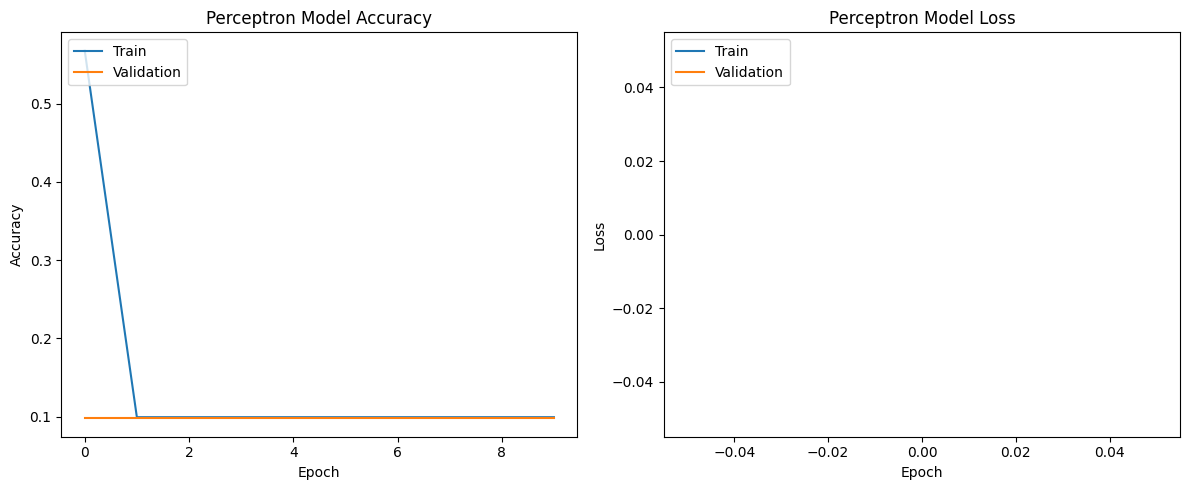

In [33]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Perceptron Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Perceptron Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

### Perceptron Model - Training History Visualization

In [34]:
print(f"Perceptron Test Loss: {acc_prepcp[0]:.4f}, Test Accuracy: {acc_prepcp[1]:.4f}")
print(f"ANN Test Loss: {acc_ann[0]:.4f}, Test Accuracy: {acc_ann[1]:.4f}")

Perceptron Test Loss: nan, Test Accuracy: 0.0980
ANN Test Loss: nan, Test Accuracy: 0.0980


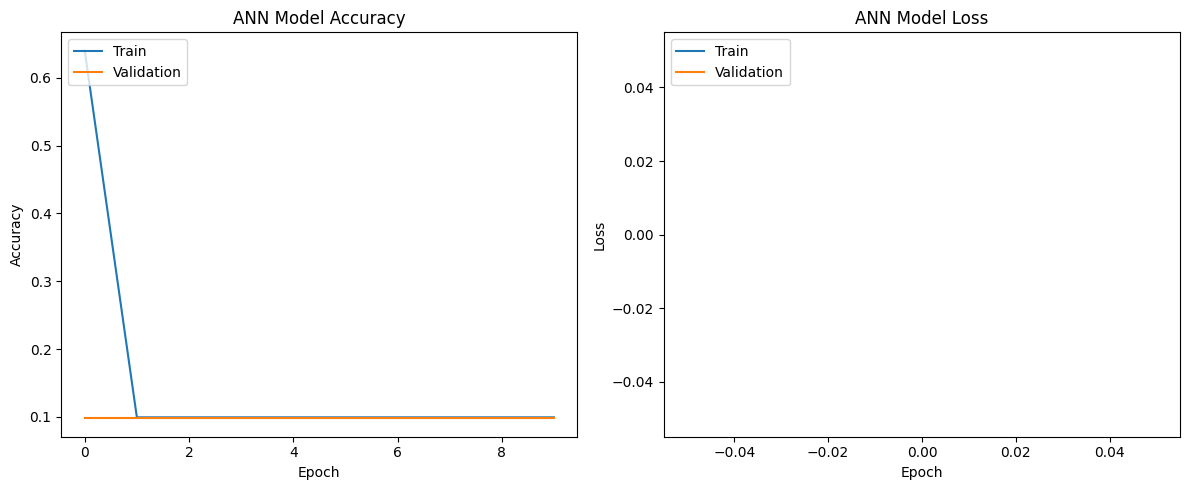

In [35]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(histroy_ann.history['accuracy'])
plt.plot(histroy_ann.history['val_accuracy'])
plt.title('ANN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(histroy_ann.history['loss'])
plt.plot(histroy_ann.history['val_loss'])
plt.title('ANN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

### Confusion Matrices for Model Evaluation

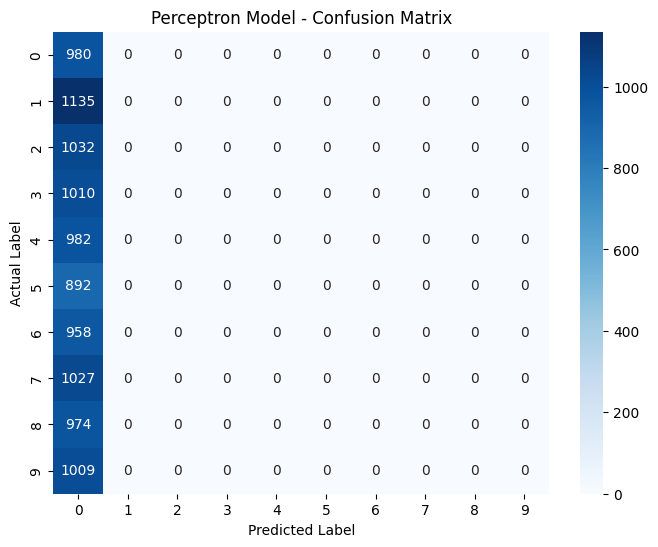

In [36]:
# Confusion Matrix for Perceptron Model
cm_perceptron = confusion_matrix(actual_labels, perceptron_predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_perceptron, annot=True, fmt='d', cmap='Blues')
plt.title('Perceptron Model - Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

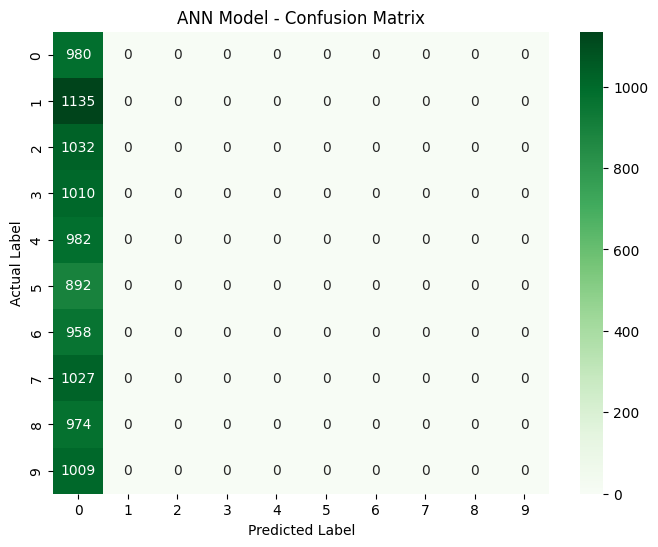

In [37]:
# Confusion Matrix for ANN Model
cm_ann = confusion_matrix(actual_labels, ann_predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Greens')
plt.title('ANN Model - Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

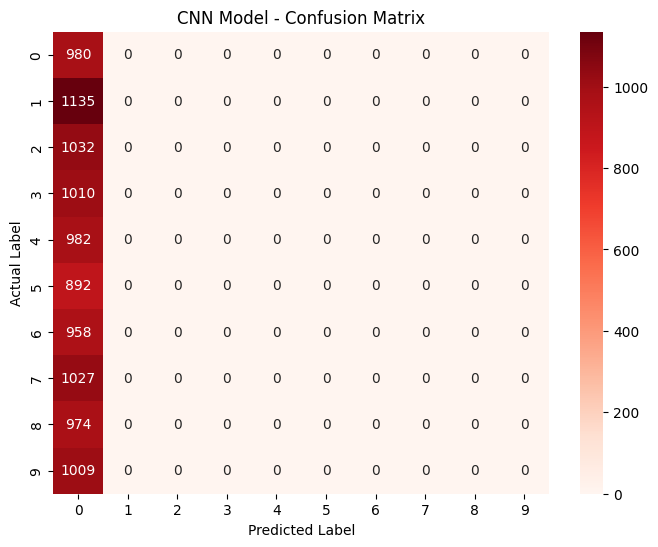

In [38]:
# Confusion Matrix for CNN Model
cm_cnn = confusion_matrix(actual_labels, cnn_predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Reds')
plt.title('CNN Model - Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

The confusion matrices provide a detailed breakdown of correct and incorrect classifications for each digit by each model. The diagonal elements represent the number of correctly classified instances for each class, while off-diagonal elements indicate misclassifications.